<a href="https://colab.research.google.com/github/gregoirehendrix/Master_Thesis/blob/main/towers_layout_groups.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nombre d’unités CSP pour 1 PB : 20
CAP (max tours par branche) : 5
20 tours → Grille 9×9
Contrainte CAP = 5

LONGUEUR INSTALLÉE = 4100.0 m


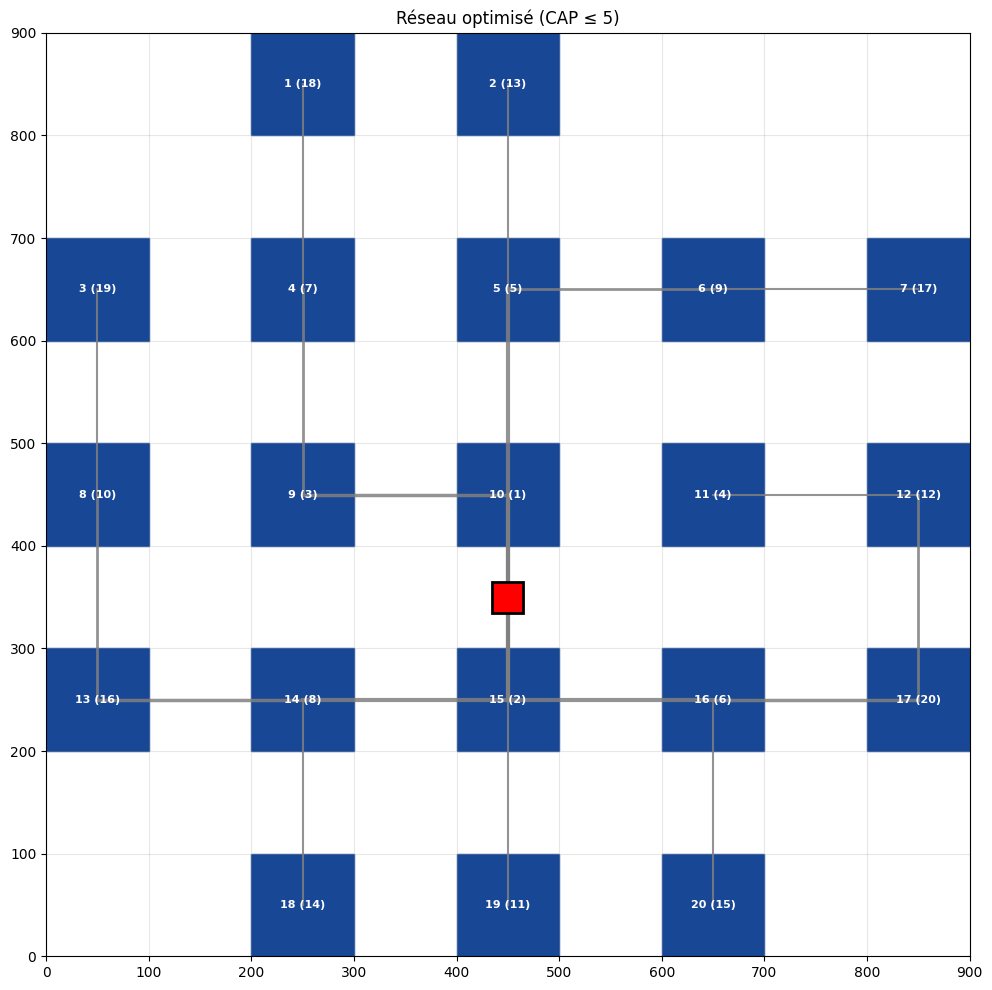


=== LONGUEURS TOTALES PAR DIAMÈTRE ===
3" : 1000.00 m
2" : 900.00 m
2 1/2" : 600.00 m
1 1/4" : 1600.00 m

=== VERIFICATION DETAILLÉE DES TUYAUX ===
Enfant → Parent | Charge | Diamètre | Longueur (m)
---------------------------------------------------
1 → 0 | 4 | 3" | 100.00
2 → 0 | 2 | 2" | 100.00
3 → 1 | 3 | 2 1/2" | 200.00
4 → 12 | 1 | 1 1/4" | 200.00
5 → 0 | 4 | 3" | 300.00
6 → 0 | 5 | 3" | 300.00
7 → 3 | 2 | 2" | 200.00
8 → 0 | 5 | 3" | 300.00
9 → 5 | 2 | 2" | 200.00
10 → 16 | 2 | 2" | 200.00
11 → 2 | 1 | 1 1/4" | 200.00
12 → 20 | 2 | 2" | 200.00
13 → 5 | 1 | 1 1/4" | 200.00
14 → 8 | 1 | 1 1/4" | 200.00
15 → 6 | 1 | 1 1/4" | 200.00
16 → 8 | 3 | 2 1/2" | 200.00
17 → 9 | 1 | 1 1/4" | 200.00
18 → 7 | 1 | 1 1/4" | 200.00
19 → 10 | 1 | 1 1/4" | 200.00
20 → 6 | 3 | 2 1/2" | 200.00
---------------------------------------------------
Longueur totale recalculée : 4100.00 m
Différence avec total_len : 0.00 m


In [1]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from itertools import product
import math
from collections import deque

# 🟦 sera défini par l’utilisateur au lancement
DIST_UNITE = None

# ===================== UTILITAIRES DE BASE =====================

def coord_reelle(p, M):
    i, j = p
    return j * DIST_UNITE, i * DIST_UNITE

def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def grille_bleues_pour_nb(nb_bleus, step=2):
    n_side = math.ceil(math.sqrt(nb_bleus))
    M_indices = step * (n_side - 1) + 1

    while True:
        n_pos_x = (M_indices - 1) // step + 1
        max_bleus = n_pos_x ** 2
        if max_bleus >= nb_bleus:
            break
        M_indices += step

    M = M_indices
    pos_sparse = list(product(range(0, M, step), range(0, M, step)))

    taille_totale = (M - 1) * DIST_UNITE
    cx, cy = taille_totale / 2, taille_totale / 2

    sparse_coords = np.array([coord_reelle(p, M) for p in pos_sparse])
    dists_centre = np.sqrt((sparse_coords[:, 0] - cx)**2 + (sparse_coords[:, 1] - cy)**2)

    idx_proches = np.argsort(dists_centre)[:nb_bleus]
    return [pos_sparse[i] for i in idx_proches], M

# ===================== OPTIMISATION AVEC CAPACITÉ =====================

class Component:
    __slots__ = ("nodes", "size", "internal_cost", "pb_cost", "pb_node", "edges")

    def __init__(self, node, dist_to_pb):
        self.nodes = set()
        self.size = 0
        self.internal_cost = 0.0
        self.pb_cost = float('inf')
        self.pb_node = None
        self.edges = []

        if node != 0:
            self.nodes = {node}
            self.size = 1
            self.pb_cost = dist_to_pb[node]
            self.pb_node = node


def build_capacitated_forest_for_candidate(bleus_pos, red_pos, M, CAP=4):
    B = len(bleus_pos)
    red_xy = coord_reelle(red_pos, M)
    blue_xy = [coord_reelle(p, M) for p in bleus_pos]

    coords = [red_xy] + blue_xy

    dist_to_pb = {b: manhattan(coords[b], coords[0]) for b in range(1, B+1)}

    pair_dist = {}
    for i in range(1, B+1):
        for j in range(i+1, B+1):
            pair_dist[(i, j)] = manhattan(coords[i], coords[j])

    components = [Component(b, dist_to_pb) for b in range(1, B+1)]

    # Heuristique savings CAPACITÉ
    while True:
        best = None
        nC = len(components)
        if nC <= 1:
            break

        for a in range(nC):
            A = components[a]
            for b in range(a+1, nC):
                Bc = components[b]
                if A.size + Bc.size > CAP:
                    continue

                d_uv = math.inf
                u_best = v_best = None
                for u in A.nodes:
                    for v in Bc.nodes:
                        i, j = (u, v) if u < v else (v, u)
                        d = pair_dist[(i, j)]
                        if d < d_uv:
                            d_uv = d
                            u_best, v_best = u, v

                saving = max(A.pb_cost, Bc.pb_cost) - d_uv
                if saving > 1e-9:
                    if best is None or saving > best[0]:
                        best = (saving, a, b, u_best, v_best, d_uv)

        if best is None:
            break

        _, ia, ib, u, v, d_uv = best
        A = components[ia]
        Bc = components[ib]

        C = Component(0, dist_to_pb)
        C.nodes = A.nodes.union(Bc.nodes)
        C.size = A.size + Bc.size
        C.internal_cost = A.internal_cost + Bc.internal_cost + d_uv

        if A.pb_cost <= Bc.pb_cost:
            C.pb_cost = A.pb_cost
            C.pb_node = A.pb_node
        else:
            C.pb_cost = Bc.pb_cost
            C.pb_node = Bc.pb_node

        C.edges = A.edges + Bc.edges + [(u, v, d_uv)]

        for idx in sorted([ia, ib], reverse=True):
            components.pop(idx)
        components.append(C)

    total_installed_length = 0.0
    for C in components:
        total_installed_length += C.internal_cost + C.pb_cost

    parent = [-1] + [None] * B

    adjacency = {b: set() for b in range(1, B+1)}
    for C in components:
        for (u, v, _) in C.edges:
            adjacency[u].add(v)
            adjacency[v].add(u)

    for C in components:
        root = C.pb_node
        if root is None:
            continue
        q = deque([root])
        visited = {root}
        parent[root] = 0
        while q:
            u = q.popleft()
            for w in adjacency[u]:
                if w not in visited:
                    visited.add(w)
                    parent[w] = u
                    q.append(w)

    def path_length_to_root(b):
        dist = 0.0
        u = b
        while parent[u] != 0:
            dist += manhattan(coords[u], coords[parent[u]])
            u = parent[u]
        dist += manhattan(coords[u], coords[0])
        return dist

    per_blue_path = {b: path_length_to_root(b) for b in range(1, B+1)}

    return parent, coords, total_installed_length, per_blue_path, components

def choose_best_power_block_capacitated(bleus_pos, M, CAP=4):
    bleus_set = set(bleus_pos)
    candidates = [(i, j) for i in range(M) for j in range(M) if (i, j) not in bleus_set]

    best = None
    for red_pos in candidates:
        out = build_capacitated_forest_for_candidate(bleus_pos, red_pos, M, CAP)
        parent, coords, total_len, per_blue_path, comps = out
        if best is None or total_len < best["total_len"]:
            best = dict(
                red_pos=red_pos,
                parent=parent,
                coords=coords,
                total_len=total_len,
                per_blue_path=per_blue_path,
                comps=comps
            )
    return best

# ===================== TRI D’AFFICHAGE VISUEL =====================

def compute_visual_order(bleus_pos):
    """
    Retourne :
      - liste triée visuellement [(internal_id, (i,j)), ...]
      - mapping internal_id -> visual_id
    """
    sorted_vis = sorted(
        list(enumerate(bleus_pos, start=1)),
        key=lambda x: (-x[1][0], x[1][1])  # haut -> bas, gauche -> droite
    )
    mapping = {internal: visual for visual, (internal, _) in enumerate(sorted_vis, start=1)}
    return sorted_vis, mapping

# ===================== AFFICHAGE =====================

def compute_subtree_sizes(parent):
    n = len(parent)
    children = [[] for _ in range(n)]
    for v in range(1, n):
        p = parent[v]
        if p >= 0:
            children[p].append(v)

    order = []
    stack = [0]
    while stack:
        u = stack.pop()
        order.append(u)
        for v in children[u]:
            stack.append(v)

    size = [0]*n
    for u in reversed(order):
        s = 0 if u == 0 else 1
        for v in children[u]:
            s += size[v]
        size[u] = s
    return size, children


def plot_network_with_pipes(bleus_pos, red_pos, parent, coords, M, title="Réseau optimisé"):
    total = M * DIST_UNITE

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_aspect('equal', adjustable='box')

    # 🟦 TRI VISUEL + MAP
    bleus_visuels, map_int_to_vis = compute_visual_order(bleus_pos)

    # 🟦 AFFICHAGE BLEUS AVEC NUMÉROTATION VISUELLE
    for internal_id, (i, j) in bleus_visuels:
        display_id = map_int_to_vis[internal_id]
        x, y = coord_reelle((i, j), M)

        rect = Rectangle((x, y), DIST_UNITE, DIST_UNITE,
                         facecolor='#0B3D91', edgecolor='#0B3D91',
                         alpha=0.95, zorder=1)
        ax.add_patch(rect)

        ax.text(
            x + DIST_UNITE/2, y + DIST_UNITE/2,
            f"{display_id} ({internal_id})",
            ha='center', va='center',
            color='white', fontsize=8, fontweight='bold', zorder=5
        )

    # PB
    xR, yR = coord_reelle(red_pos, M)
    TAILLE_PB = min(30, DIST_UNITE)
    x_c = xR + (DIST_UNITE - TAILLE_PB)/2
    y_c = yR + (DIST_UNITE - TAILLE_PB)/2
    rect = Rectangle((x_c, y_c), TAILLE_PB, TAILLE_PB,
                     facecolor='red', edgecolor='black', linewidth=2, zorder=10)
    ax.add_patch(rect)

    # Tuyaux
    sizes, children = compute_subtree_sizes(parent)
    n = len(parent)
    for v in range(1, n):
        p = parent[v]
        (x1, y1) = coords[v]
        (x2, y2) = coords[p]

        c1 = (x1 + DIST_UNITE/2, y1 + DIST_UNITE/2)
        c2 = (x2 + DIST_UNITE/2, y2 + DIST_UNITE/2)

        w = 1.0 + 0.5 * min(sizes[v], 4)
        ax.plot([c1[0], c2[0]], [c1[1], c1[1]], color='gray', linewidth=w, alpha=0.85, zorder=3)
        ax.plot([c2[0], c2[0]], [c1[1], c2[1]], color='gray', linewidth=w, alpha=0.85, zorder=3)

    ax.set_xlim(0, total)
    ax.set_ylim(0, total)
    ax.grid(True, alpha=0.3)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# ===================== CALCUL CHARGES + DIAMÈTRES + LONGUEURS =====================

# Table de correspondance charge -> diamètre (peut être adaptée)
DIAM_TABLE = {
    1: '1 1/4"',
    2: '2"',
    3: '2 1/2"',
    4: '3"',
    5: '3"'  # au-delà, on garde le diamètre max défini
}

def compute_pipe_charges_and_diameters(parent, nb_units, diameter_table):
    """
    Calcule la charge (nb d’unités aval) pour chaque branche et
    attribue un diamètre en fonction de la charge.
    parent : liste de taille nb_units+1 avec parent[0] inutilisé (= -1), parent[v] = père (0 = PB)
    """
    # Construction enfants
    children = {i: [] for i in range(nb_units+1)}  # 0..nb_units
    for child in range(1, nb_units+1):
        par = parent[child]
        if par is None:
            continue
        children[par].append(child)

    # DFS pour charges
    charge = {}
    def dfs(node):
        if node != 0 and len(children[node]) == 0:
            charge[node] = 1
            return 1
        total = 1 if node != 0 else 0
        for ch in children[node]:
            total += dfs(ch)
        charge[node] = total
        return total

    dfs(0)

    # Attribution diamètre par branche (child -> parent)
    pipe_info = {}
    max_key = max(diameter_table.keys())
    for b in range(1, nb_units+1):
        p = parent[b]
        if p is None:
            continue
        c = charge[b]
        diam = diameter_table[c] if c in diameter_table else diameter_table[max_key]
        pipe_info[(b, p)] = dict(charge=c, diameter=diam)

    return pipe_info, charge

def compute_length_per_diameter(parent, coords, pipe_info):
    """
    Additionne les longueurs (Manhattan) par diamètre.
    coords : liste où coords[0] = PB, coords[1..B] = bleus
    """
    length_per_diam = {}
    for (child, par), info in pipe_info.items():
        diam = info["diameter"]
        x1, y1 = coords[child]
        x2, y2 = coords[par]
        dist = abs(x1 - x2) + abs(y1 - y2)
        length_per_diam[diam] = length_per_diam.get(diam, 0) + dist
    return length_per_diam

# ===================== PIPELINE GLOBAL =====================

def optimize_pb_and_grouping_capacitated(nb_bleus, step=2, CAP=4):
    bleus_pos, M = grille_bleues_pour_nb(nb_bleus, step)
    print(f"{len(bleus_pos)} tours → Grille {M}×{M}")
    print(f"Contrainte CAP = {CAP}")

    best = choose_best_power_block_capacitated(bleus_pos, M, CAP=CAP)

    red_pos = best["red_pos"]
    parent = best["parent"]
    coords = best["coords"]
    total_len = best["total_len"]

    print("\nLONGUEUR INSTALLÉE =", total_len, "m")

    plot_network_with_pipes(
        bleus_pos=bleus_pos,
        red_pos=red_pos,
        parent=parent,
        coords=coords,
        M=M,
        title=f"Réseau optimisé (CAP ≤ {CAP})"
    )

    # ===== CALCUL DIAMÈTRES & LONGUEURS =====
    pipe_info, charges = compute_pipe_charges_and_diameters(parent, len(bleus_pos), DIAM_TABLE)
    lengths = compute_length_per_diameter(parent, coords, pipe_info)

    print("\n=== LONGUEURS TOTALES PAR DIAMÈTRE ===")
    # Tri optionnel par “ordre” de diamètre (facultatif — ici on garde l’ordre d’insertion)
    for diam, L in lengths.items():
        print(f"{diam} : {L:.2f} m")

    # ===== VERIFICATION DETAILLÉE (audit Cas B) =====
    print("\n=== VERIFICATION DETAILLÉE DES TUYAUX ===")
    print("Enfant → Parent | Charge | Diamètre | Longueur (m)")
    print("---------------------------------------------------")

    total_recalc = 0.0

    for (child, par), info in pipe_info.items():
        x1, y1 = coords[child]
        x2, y2 = coords[par]
        length = abs(x1 - x2) + abs(y1 - y2)

        print(f"{child} → {par} | {info['charge']} | {info['diameter']} | {length:.2f}")

        total_recalc += length

    print("---------------------------------------------------")
    print(f"Longueur totale recalculée : {total_recalc:.2f} m")
    print(f"Différence avec total_len : {abs(total_recalc - total_len):.2f} m")

# ===================== MAIN =====================

if __name__ == "__main__":
    nb = int(input("Nombre d’unités CSP pour 1 PB : "))
    DIST_UNITE = 100
    CAP = int(input("CAP (max tours par branche) : "))

    optimize_pb_and_grouping_capacitated(nb, step=2, CAP=CAP)

Nombre d’unités CSP pour 1 PB : 20
CAP (max tours par branche) : 5
20 tours → Grille 9×9
Contrainte CAP = 5

LONGUEUR INSTALLÉE = 4100.0 m


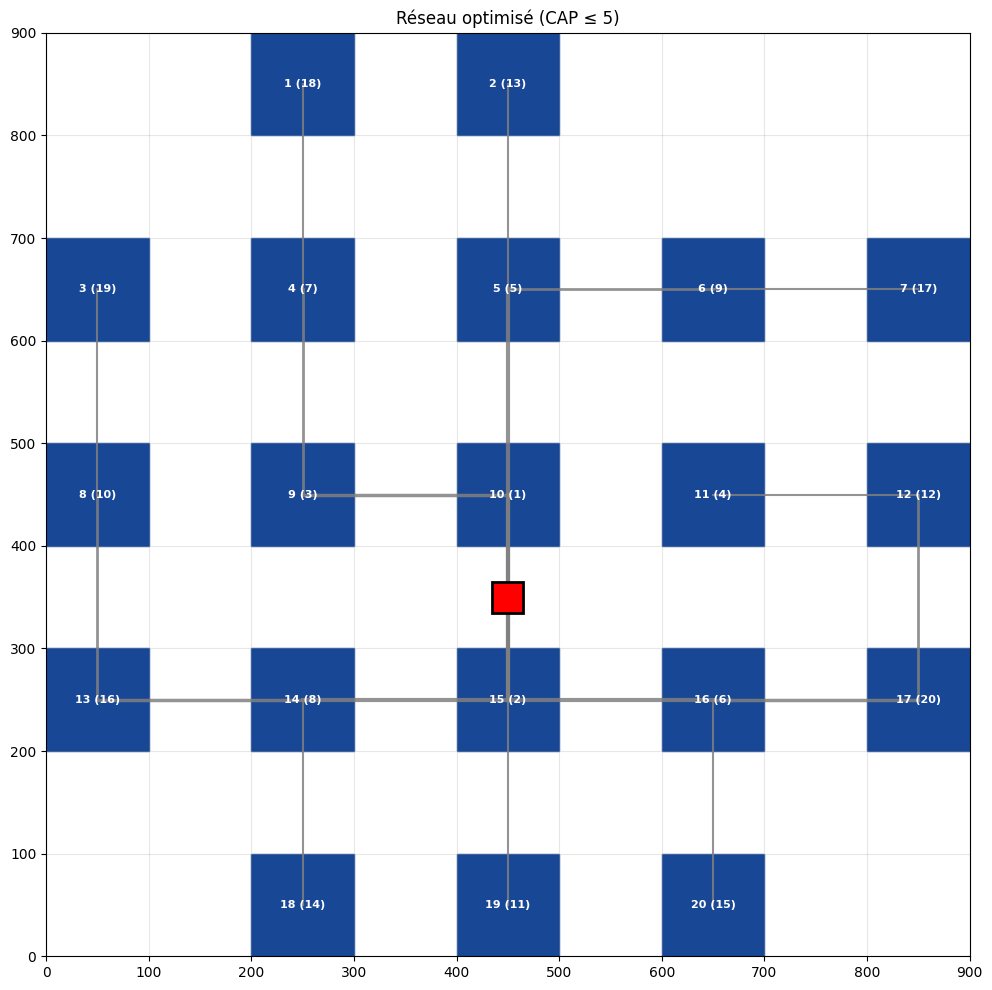


=== LONGUEURS TOTALES PAR DIAMÈTRE ===
3" : 1000.00 m
2" : 900.00 m
2 1/2" : 600.00 m
1 1/4" : 1600.00 m

=== VERIFICATION DETAILLEE DES TUYAUX (IDs VISUELS) ===
Enfant(visuel) → Parent(visuel) | Charge | Diamètre | Longueur (m)
---------------------------------------------------
10 → PB | 4 | 3" | 100.00
15 → PB | 2 | 2" | 100.00
9 → 10 | 3 | 2 1/2" | 200.00
11 → 12 | 1 | 1 1/4" | 200.00
5 → PB | 4 | 3" | 300.00
16 → PB | 5 | 3" | 300.00
4 → 9 | 2 | 2" | 200.00
14 → PB | 5 | 3" | 300.00
6 → 5 | 2 | 2" | 200.00
8 → 13 | 2 | 2" | 200.00
19 → 15 | 1 | 1 1/4" | 200.00
12 → 17 | 2 | 2" | 200.00
2 → 5 | 1 | 1 1/4" | 200.00
18 → 14 | 1 | 1 1/4" | 200.00
20 → 16 | 1 | 1 1/4" | 200.00
13 → 14 | 3 | 2 1/2" | 200.00
7 → 6 | 1 | 1 1/4" | 200.00
1 → 4 | 1 | 1 1/4" | 200.00
3 → 8 | 1 | 1 1/4" | 200.00
17 → 16 | 3 | 2 1/2" | 200.00
---------------------------------------------------
Longueur totale recalculée : 4100.00 m
Différence avec total_len : 0.00 m


In [1]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from itertools import product
import math
from collections import deque

# 🟦 sera défini par l’utilisateur au lancement
DIST_UNITE = None

# ===================== UTILITAIRES DE BASE =====================

def coord_reelle(p, M):
    i, j = p
    return j * DIST_UNITE, i * DIST_UNITE

def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def grille_bleues_pour_nb(nb_bleus, step=2):
    n_side = math.ceil(math.sqrt(nb_bleus))
    M_indices = step * (n_side - 1) + 1

    while True:
        n_pos_x = (M_indices - 1) // step + 1
        max_bleus = n_pos_x ** 2
        if max_bleus >= nb_bleus:
            break
        M_indices += step

    M = M_indices
    pos_sparse = list(product(range(0, M, step), range(0, M, step)))

    taille_totale = (M - 1) * DIST_UNITE
    cx, cy = taille_totale / 2, taille_totale / 2

    sparse_coords = np.array([coord_reelle(p, M) for p in pos_sparse])
    dists_centre = np.sqrt((sparse_coords[:, 0] - cx)**2 + (sparse_coords[:, 1] - cy)**2)

    idx_proches = np.argsort(dists_centre)[:nb_bleus]
    return [pos_sparse[i] for i in idx_proches], M

# ===================== OPTIMISATION AVEC CAPACITÉ =====================

class Component:
    __slots__ = ("nodes", "size", "internal_cost", "pb_cost", "pb_node", "edges")

    def __init__(self, node, dist_to_pb):
        self.nodes = set()
        self.size = 0
        self.internal_cost = 0.0
        self.pb_cost = float('inf')
        self.pb_node = None
        self.edges = []

        if node != 0:
            self.nodes = {node}
            self.size = 1
            self.pb_cost = dist_to_pb[node]
            self.pb_node = node

def build_capacitated_forest_for_candidate(bleus_pos, red_pos, M, CAP=4):
    B = len(bleus_pos)
    red_xy = coord_reelle(red_pos, M)
    blue_xy = [coord_reelle(p, M) for p in bleus_pos]

    coords = [red_xy] + blue_xy

    dist_to_pb = {b: manhattan(coords[b], coords[0]) for b in range(1, B+1)}

    pair_dist = {}
    for i in range(1, B+1):
        for j in range(i+1, B+1):
            pair_dist[(i, j)] = manhattan(coords[i], coords[j])

    components = [Component(b, dist_to_pb) for b in range(1, B+1)]

    while True:
        best = None
        nC = len(components)
        if nC <= 1:
            break

        for a in range(nC):
            A = components[a]
            for b in range(a+1, nC):
                Bc = components[b]
                if A.size + Bc.size > CAP:
                    continue

                d_uv = math.inf
                u_best = v_best = None
                for u in A.nodes:
                    for v in Bc.nodes:
                        i, j = (u, v) if u < v else (v, u)
                        d = pair_dist[(i, j)]
                        if d < d_uv:
                            d_uv = d
                            u_best, v_best = u, v

                saving = max(A.pb_cost, Bc.pb_cost) - d_uv
                if saving > 1e-9:
                    if best is None or saving > best[0]:
                        best = (saving, a, b, u_best, v_best, d_uv)

        if best is None:
            break

        _, ia, ib, u, v, d_uv = best
        A = components[ia]
        Bc = components[ib]

        C = Component(0, dist_to_pb)
        C.nodes = A.nodes.union(Bc.nodes)
        C.size = A.size + Bc.size
        C.internal_cost = A.internal_cost + Bc.internal_cost + d_uv

        if A.pb_cost <= Bc.pb_cost:
            C.pb_cost = A.pb_cost
            C.pb_node = A.pb_node
        else:
            C.pb_cost = Bc.pb_cost
            C.pb_node = Bc.pb_node

        C.edges = A.edges + Bc.edges + [(u, v, d_uv)]

        for idx in sorted([ia, ib], reverse=True):
            components.pop(idx)
        components.append(C)

    total_installed_length = 0.0
    for C in components:
        total_installed_length += C.internal_cost + C.pb_cost

    parent = [-1] + [None] * B

    adjacency = {b: set() for b in range(1, B+1)}
    for C in components:
        for (u, v, _) in C.edges:
            adjacency[u].add(v)
            adjacency[v].add(u)

    for C in components:
        root = C.pb_node
        if root is None:
            continue
        q = deque([root])
        visited = {root}
        parent[root] = 0
        while q:
            u = q.popleft()
            for w in adjacency[u]:
                if w not in visited:
                    visited.add(w)
                    parent[w] = u
                    q.append(w)

    def path_length_to_root(b):
        dist = 0.0
        u = b
        while parent[u] != 0:
            dist += manhattan(coords[u], coords[parent[u]])
            u = parent[u]
        dist += manhattan(coords[u], coords[0])
        return dist

    per_blue_path = {b: path_length_to_root(b) for b in range(1, B+1)}

    return parent, coords, total_installed_length, per_blue_path, components

def choose_best_power_block_capacitated(bleus_pos, M, CAP=4):
    bleus_set = set(bleus_pos)
    candidates = [(i, j) for i in range(M) for j in range(M) if (i, j) not in bleus_set]

    best = None
    for red_pos in candidates:
        out = build_capacitated_forest_for_candidate(bleus_pos, red_pos, M, CAP)
        parent, coords, total_len, per_blue_path, comps = out
        if best is None or total_len < best["total_len"]:
            best = dict(
                red_pos=red_pos,
                parent=parent,
                coords=coords,
                total_len=total_len,
                per_blue_path=per_blue_path,
                comps=comps
            )
    return best

# ===================== TRI D’AFFICHAGE VISUEL =====================

def compute_visual_order(bleus_pos):
    sorted_vis = sorted(
        list(enumerate(bleus_pos, start=1)),
        key=lambda x: (-x[1][0], x[1][1])
    )
    mapping = {internal: visual for visual, (internal, _) in enumerate(sorted_vis, start=1)}
    return sorted_vis, mapping

# ===================== AFFICHAGE =====================

def compute_subtree_sizes(parent):
    n = len(parent)
    children = [[] for _ in range(n)]
    for v in range(1, n):
        p = parent[v]
        if p >= 0:
            children[p].append(v)

    order = []
    stack = [0]
    while stack:
        u = stack.pop()
        order.append(u)
        for v in children[u]:
            stack.append(v)

    size = [0]*n
    for u in reversed(order):
        s = 0 if u == 0 else 1
        for v in children[u]:
            s += size[v]
        size[u] = s
    return size, children

def plot_network_with_pipes(bleus_pos, red_pos, parent, coords, M, title="Réseau optimisé"):
    total = M * DIST_UNITE
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_aspect('equal', adjustable='box')

    bleus_visuels, map_int_to_vis = compute_visual_order(bleus_pos)

    for internal_id, (i, j) in bleus_visuels:
        display_id = map_int_to_vis[internal_id]
        x, y = coord_reelle((i, j), M)

        rect = Rectangle((x, y), DIST_UNITE, DIST_UNITE,
                         facecolor='#0B3D91', edgecolor='#0B3D91',
                         alpha=0.95, zorder=1)
        ax.add_patch(rect)

        ax.text(
            x + DIST_UNITE/2, y + DIST_UNITE/2,
            f"{display_id} ({internal_id})",
            ha='center', va='center',
            color='white', fontsize=8, fontweight='bold', zorder=5
        )

    xR, yR = coord_reelle(red_pos, M)
    TAILLE_PB = min(30, DIST_UNITE)
    x_c = xR + (DIST_UNITE - TAILLE_PB)/2
    y_c = yR + (DIST_UNITE - TAILLE_PB)/2
    rect = Rectangle((x_c, y_c), TAILLE_PB, TAILLE_PB,
                     facecolor='red', edgecolor='black', linewidth=2, zorder=10)
    ax.add_patch(rect)

    sizes, children = compute_subtree_sizes(parent)
    n = len(parent)
    for v in range(1, n):
        p = parent[v]
        (x1, y1) = coords[v]
        (x2, y2) = coords[p]

        c1 = (x1 + DIST_UNITE/2, y1 + DIST_UNITE/2)
        c2 = (x2 + DIST_UNITE/2, y2 + DIST_UNITE/2)

        w = 1.0 + 0.5 * min(sizes[v], 4)
        ax.plot([c1[0], c2[0]], [c1[1], c1[1]], color='gray', linewidth=w, alpha=0.85)
        ax.plot([c2[0], c2[0]], [c1[1], c2[1]], color='gray', linewidth=w, alpha=0.85)

    ax.set_xlim(0, total)
    ax.set_ylim(0, total)
    ax.grid(True, alpha=0.3)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# ===================== CALCUL CHARGES + DIAMÈTRES + LONGUEURS =====================

DIAM_TABLE = {
    1: '1 1/4"',
    2: '2"',
    3: '2 1/2"',
    4: '3"',
    5: '3"'
}

def compute_pipe_charges_and_diameters(parent, nb_units, diameter_table):

    children = {i: [] for i in range(nb_units+1)}
    for child in range(1, nb_units+1):
        par = parent[child]
        if par is None:
            continue
        children[par].append(child)

    charge = {}
    def dfs(node):
        if node != 0 and len(children[node]) == 0:
            charge[node] = 1
            return 1
        total = 1 if node != 0 else 0
        for ch in children[node]:
            total += dfs(ch)
        charge[node] = total
        return total

    dfs(0)

    pipe_info = {}
    max_key = max(diameter_table.keys())
    for b in range(1, nb_units+1):
        p = parent[b]
        if p is None:
            continue
        c = charge[b]
        diam = diameter_table[c] if c in diameter_table else diameter_table[max_key]
        pipe_info[(b, p)] = dict(charge=c, diameter=diam)

    return pipe_info, charge

def compute_length_per_diameter(parent, coords, pipe_info):
    length_per_diam = {}
    for (child, par), info in pipe_info.items():
        diam = info["diameter"]
        x1, y1 = coords[child]
        x2, y2 = coords[par]
        dist = abs(x1 - x2) + abs(y1 - y2)
        length_per_diam[diam] = length_per_diam.get(diam, 0) + dist
    return length_per_diam

# ===================== PIPELINE GLOBAL =====================

def optimize_pb_and_grouping_capacitated(nb_bleus, step=2, CAP=4):
    bleus_pos, M = grille_bleues_pour_nb(nb_bleus, step)
    print(f"{len(bleus_pos)} tours → Grille {M}×{M}")
    print(f"Contrainte CAP = {CAP}")

    best = choose_best_power_block_capacitated(bleus_pos, M, CAP=CAP)

    red_pos = best["red_pos"]
    parent = best["parent"]
    coords = best["coords"]
    total_len = best["total_len"]

    # ---- Mapping interne -> visuel pour AUDIT ----
    sorted_vis = sorted(
        list(enumerate(bleus_pos, start=1)),
        key=lambda x: (-x[1][0], x[1][1])
    )
    int_to_vis = {internal: vis for vis, (internal, _) in enumerate(sorted_vis, start=1)}

    print("\nLONGUEUR INSTALLÉE =", total_len, "m")

    plot_network_with_pipes(
        bleus_pos=bleus_pos,
        red_pos=red_pos,
        parent=parent,
        coords=coords,
        M=M,
        title=f"Réseau optimisé (CAP ≤ {CAP})"
    )

    pipe_info, charges = compute_pipe_charges_and_diameters(parent, len(bleus_pos), DIAM_TABLE)
    lengths = compute_length_per_diameter(parent, coords, pipe_info)

    print("\n=== LONGUEURS TOTALES PAR DIAMÈTRE ===")
    for diam, L in lengths.items():
        print(f"{diam} : {L:.2f} m")

    # ===== AUDIT AVEC IDs VISUELS =====
    print("\n=== VERIFICATION DETAILLEE DES TUYAUX (IDs VISUELS) ===")
    print("Enfant(visuel) → Parent(visuel) | Charge | Diamètre | Longueur (m)")
    print("---------------------------------------------------")

    total_recalc = 0.0
    for (child, par), info in pipe_info.items():
        x1, y1 = coords[child]
        x2, y2 = coords[par]
        length = abs(x1 - x2) + abs(y1 - y2)

        child_v = int_to_vis.get(child, child)
        parent_v = "PB" if par == 0 else int_to_vis.get(par, par)

        print(f"{child_v} → {parent_v} | {info['charge']} | {info['diameter']} | {length:.2f}")
        total_recalc += length

    print("---------------------------------------------------")
    print(f"Longueur totale recalculée : {total_recalc:.2f} m")
    print(f"Différence avec total_len : {abs(total_recalc - total_len):.2f} m")

# ===================== MAIN =====================

if __name__ == "__main__":
    nb = int(input("Nombre d’unités CSP pour 1 PB : "))
    DIST_UNITE = 100
    CAP = int(input("CAP (max tours par branche) : "))

    optimize_pb_and_grouping_capacitated(nb, step=2, CAP=CAP)